# 03 — Portfolio Fit and Diversification Analysis

This notebook evaluates how each fictional candidate and selected public alternative would affect EDEN's current portfolio.

The objective is not to identify the strongest standalone stock. The objective is to test whether adding Orion, Cleanergy, NovaTerra, or an investable public alternative improves the portfolio's diversification, risk-return profile, and strategic exposure.

The analysis separates the portfolio decision from benchmark context:
- Current EDEN holdings and fictional candidates are used for the main portfolio scenario analysis.
- Selected public alternatives are included only where they directly challenge the single-name recommendation.
- The notebook avoids repeating the detailed standalone candidate-vs-peer analysis from notebook 02.

Key outputs:
- Full correlation matrix including current holdings, candidates, and selected public alternatives
- Current vs post-investment portfolio scenarios
- Portfolio return, volatility, Sharpe ratio, and max drawdown
- Incremental impact of each candidate and public alternative
- Diversification and portfolio-fit interpretation


In [2]:
# Import libraries and define project paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf  # Used to download current portfolio holdings 

# Detect project root by searching upward for expected folders
current_path = Path.cwd()
candidate_roots = [current_path] + list(current_path.parents)

PROJECT_ROOT = None

for path in candidate_roots:
    if all((path / folder).exists() for folder in ["data", "notebooks", "outputs"]):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not detect project root. Expected folders: data, notebooks, outputs."
    )

# Define project folders
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_CHARTS = PROJECT_ROOT / "outputs" / "charts"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"

# Create output folders if missing
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_CHARTS.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

# Validate raw data folder
if not DATA_RAW.exists():
    raise FileNotFoundError(f"Missing raw data folder: {DATA_RAW}")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Core assumptions
TRADING_DAYS = 252
RISK_FREE_RATE = 0.03

print("Project root detected:", PROJECT_ROOT)
print("Trading days assumption:", TRADING_DAYS)
print("Risk-free rate assumption:", f"{RISK_FREE_RATE:.1%}")
print("Setup complete.")

Project root detected: c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment
Trading days assumption: 252
Risk-free rate assumption: 3.0%
Setup complete.


In [3]:
# Define current EDEN portfolio and new investment size

portfolio_tickers = {
    "ASML": "ASML.AS",
    "NOVO-B": "NOVO-B.CO",
    "PVH": "PVH",
    "XLU": "XLU",
    "GLD": "GLD",
}

portfolio_values = {
    "ASML": 5000,
    "NOVO-B": 5000,
    "PVH": 7500,
    "XLU": 7500,
    "GLD": 10000,
}

NEW_INVESTMENT = 5000

portfolio_value_total = sum(portfolio_values.values())
post_investment_value = portfolio_value_total + NEW_INVESTMENT

portfolio_summary = pd.DataFrame({
    "Ticker": pd.Series(portfolio_tickers),
    "Market Value EUR": pd.Series(portfolio_values),
})

portfolio_summary["Current Weight"] = (
    portfolio_summary["Market Value EUR"] / portfolio_value_total
)

display(portfolio_summary)

print(f"Current portfolio value: €{portfolio_value_total:,.0f}")
print(f"New investment size: €{NEW_INVESTMENT:,.0f}")
print(f"Post-investment portfolio value: €{post_investment_value:,.0f}")
print(
    "New candidate position weight after investment: "
    f"{NEW_INVESTMENT / post_investment_value:.2%}"
)

,Ticker,Market Value EUR,Current Weight
ASML,ASML.AS,5000,0.142857
NOVO-B,NOVO-B.CO,5000,0.142857
PVH,PVH,7500,0.214286
XLU,XLU,7500,0.214286
GLD,GLD,10000,0.285714


Current portfolio value: €35,000
New investment size: €5,000
Post-investment portfolio value: €40,000
New candidate position weight after investment: 12.50%


In [4]:
# Define core asset groups used throughout notebook 03

current_holdings = list(portfolio_tickers.keys())
candidates = ["Orion", "Cleanergy", "NovaTerra"]

# Selected public alternatives used only for portfolio-level investable context.
# We keep one clean alternative per fictional candidate to avoid overcrowding
# the portfolio-fit notebook with all comparable stocks from notebook 02.
public_alternative_tickers = {
    "SMH": "SMH",    # Diversified semiconductor ETF; alternative to Orion
    "GRID": "GRID",  # Smart-grid / infrastructure ETF; alternative to Cleanergy
    "MOO": "MOO",    # Agribusiness ETF; alternative to NovaTerra
}

public_alternatives = list(public_alternative_tickers.keys())
scenario_assets = candidates + public_alternatives

asset_type_map = {
    **{candidate: "Fictional Candidate" for candidate in candidates},
    **{asset: "Public Alternative ETF" for asset in public_alternatives},
}

print("Current holdings:", current_holdings)
print("Fictional candidates:", candidates)
print("Public alternatives included in scenario testing:", public_alternatives)


Current holdings: ['ASML', 'NOVO-B', 'PVH', 'XLU', 'GLD']
Fictional candidates: ['Orion', 'Cleanergy', 'NovaTerra']
Public alternatives included in scenario testing: ['SMH', 'GRID', 'MOO']


In [5]:
# Load candidate price data from raw CSV files

candidate_files = {
    "Orion": DATA_RAW / "orion_eod.csv",
    "Cleanergy": DATA_RAW / "cleanergy_eod.csv",
    "NovaTerra": DATA_RAW / "novaterra_eod.csv",
}

candidate_prices_dict = {}

for candidate, file_path in candidate_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing candidate file for {candidate}: {file_path}")

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.lower().str.strip()

    if "date" not in df.columns:
        raise ValueError(
            f"No date column found in {file_path}. "
            f"Available columns: {df.columns.tolist()}"
        )

    if "adj close" in df.columns:
        price_col = "adj close"
    elif "adj_close" in df.columns:
        price_col = "adj_close"
    elif "close" in df.columns:
        price_col = "close"
    else:
        raise ValueError(
            f"No close price column found in {file_path}. "
            f"Available columns: {df.columns.tolist()}"
        )

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    df = (
        df
        .dropna(subset=["date", price_col])
        .sort_values("date")
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")
    )

    candidate_prices_dict[candidate] = df[price_col]

candidate_prices = pd.DataFrame(candidate_prices_dict).sort_index()

candidate_data_summary = pd.DataFrame({
    "Start Date": candidate_prices.apply(lambda x: x.dropna().index.min()),
    "End Date": candidate_prices.apply(lambda x: x.dropna().index.max()),
    "Observations": candidate_prices.notna().sum(),
    "Missing Values": candidate_prices.isna().sum(),
})

print("Candidate price data summary")
display(candidate_data_summary)

print("\nCombined candidate price data")
print(f"Start: {candidate_prices.index.min().date()}")
print(f"End: {candidate_prices.index.max().date()}")
print(f"Observations: {len(candidate_prices)}")

display(candidate_prices.head())
display(candidate_prices.tail())

Candidate price data summary


,Start Date,End Date,Observations,Missing Values
Orion,2019-06-20,2026-02-25,1745,1836
Cleanergy,2018-01-02,2026-05-22,2189,1392
NovaTerra,2012-08-31,2026-02-25,3519,62



Combined candidate price data
Start: 2012-08-31
End: 2026-05-22
Observations: 3581


,Orion,Cleanergy,NovaTerra
date,,,
2012-08-31,NaN,NaN,30.157379
2012-09-03,NaN,NaN,29.589193
2012-09-04,NaN,NaN,29.973003
2012-09-05,NaN,NaN,30.550718
2012-09-06,NaN,NaN,29.520556


,Orion,Cleanergy,NovaTerra
date,,,
2026-05-18,NaN,14.280418,NaN
2026-05-19,NaN,14.090451,NaN
2026-05-20,NaN,14.261764,NaN
2026-05-21,NaN,14.411245,NaN
2026-05-22,NaN,14.899517,NaN


In [6]:
# Download current portfolio and selected public-alternative prices from Yahoo Finance

start_date = candidate_prices.index.min()
end_date = candidate_prices.index.max()

market_tickers = {
    **portfolio_tickers,
    **public_alternative_tickers,
}

print("Downloading current portfolio and public-alternative prices from Yahoo Finance")
print(f"Start date: {start_date.date()}")
print(f"End date: {end_date.date()}")
print("Tickers:", market_tickers)

market_raw = yf.download(
    tickers=list(market_tickers.values()),
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    interval="1d",
    auto_adjust=True,
    progress=False,
)

if market_raw.empty:
    raise ValueError(
        "Yahoo Finance returned an empty DataFrame. "
        "Check tickers, dates, or internet connection."
    )

print("Downloaded market raw data shape:", market_raw.shape)

display(market_raw.head())
display(market_raw.tail())


Start date: 2012-08-31
End date: 2026-05-22
Tickers: {'ASML': 'ASML.AS', 'NOVO-B': 'NOVO-B.CO', 'PVH': 'PVH', 'XLU': 'XLU', 'GLD': 'GLD', 'SMH': 'SMH', 'GRID': 'GRID', 'MOO': 'MOO'}
Downloaded market raw data shape: (3543, 40)


Price           Close                                                                                     High  \
Ticker        ASML.AS         GLD       GRID        MOO  NOVO-B.CO        PVH        SMH        XLU    ASML.AS   
Date                                                                                                             
2012-08-31  51.311104  164.220001  23.839954  37.094273  69.029228  92.053566  13.998528  11.499475  51.499099   
2012-09-03  51.926353         NaN        NaN        NaN  69.288185        NaN        NaN        NaN  51.926353   
2012-09-04  50.815487  164.479996  23.822855  36.886040  68.474342  92.514320  13.781991  11.543761  51.897882   
2012-09-05  51.111721  164.309998  23.874161  36.960403  69.325165  91.171272  13.684338  11.493146  51.425036   
2012-09-06  51.897884  164.889999  24.489832  37.637146  69.843086  92.700600  14.121658  11.622849  51.897884   

Price                                                                                           Low              \
Ticker             GLD       GRID        MOO  NOVO-B.CO        PVH        SMH        XLU    ASML.AS         GLD   
Date                                                                                                              
2012-08-31  164.220001  23.839954  37.243007  69.103213  92.631961  14.053723  11.553255  50.741425  159.559998   
2012-09-03         NaN        NaN        NaN  69.769097        NaN        NaN        NaN  50.940805         NaN   
2012-09-04  164.770004  23.822855  37.265313  69.473157  92.837826  13.981546  11.559579  50.701550  163.660004   
2012-09-05  164.389999  23.968221  37.071952  69.436145  92.151609  13.849925  11.556416  50.416713  163.809998   
2012-09-06  165.779999  24.489832  37.666893  70.139033  93.180970  14.130150  11.626012  50.188840  164.800003   

Price                                                                              Open                         \
Ticker           GRID        MOO  NOVO-B.CO        PVH        SMH        XLU    ASML.AS         GLD       GRID   
Date                                                                                                             
2012-08-31  23.839954  36.729873  68.585306  90.984996  13.790482  11.464677  50.952208  161.139999  23.839954   
2012-09-03        NaN        NaN  68.955243        NaN        NaN        NaN  51.294008         NaN        NaN   
2012-09-04  23.822855  36.685251  68.363362  90.690895  13.667353  11.464673  51.835215  164.110001  23.822855   
2012-09-05  23.865610  36.714991  68.696282  90.563461  13.654617  11.486819  50.581921  164.119995  23.942568   
2012-09-06  24.139244  37.049646  69.362174  91.671251  13.760763  11.508961  50.422411  165.160004  24.139244   

Price                                                                 Volume                                           \
Ticker            MOO  NOVO-B.CO        PVH        SMH        XLU    ASML.AS         GLD    GRID       MOO  NOVO-B.CO   
Date                                                                                                                    
2012-08-31  37.005030  69.103213  92.308455  13.879644  11.546928  1362043.0  18024200.0   200.0  409600.0  3858360.0   
2012-09-03        NaN  69.510141        NaN        NaN        NaN   748797.0         NaN     NaN       NaN  2606230.0   
2012-09-04  37.265313  69.288191  91.886906  13.981546  11.480490   806049.0  12034800.0   400.0  353800.0  2697500.0   
2012-09-05  36.878599  68.807263  92.151609  13.752271  11.540598  1266849.0   8401900.0   900.0  459300.0  3294270.0   
2012-09-06  37.146324  69.695110  92.053582  13.760763  11.508961  1720043.0  12961100.0  1200.0  806400.0  3538960.0   

Price                                         
Ticker            PVH        SMH         XLU  
Date                                          
2012-08-31   597400.0  5788200.0  12295800.0  
2012-09-03        NaN        NaN         NaN  
2012-09-04  1115600.0  5802200.0  25937400.0  
20

Price             Close                                                                                          High  \
Ticker          ASML.AS         GLD        GRID        MOO   NOVO-B.CO        PVH         SMH        XLU      ASML.AS   
Date                                                                                                                    
2026-05-18  1264.400024  418.429993  189.220001  81.610001  286.000000  80.298599  546.159973  43.939999  1313.199951   
2026-05-19  1249.000000  411.500000  185.009995  81.019997  287.500000  79.388954  543.960022  44.340000  1279.800049   
2026-05-20  1333.000000  417.399994  188.490005  81.050003  288.399994  84.626907  564.659973  44.509998  1336.800049   
2026-05-21  1345.199951  416.989990  190.979996  80.459999  284.149994  86.676102  567.880005  45.000000  1361.199951   
2026-05-22  1409.000000  413.820007  192.500000  80.269997  289.000000  88.885239  576.320007  45.349998  1412.599976   

Price                                                                                                Low              \
Ticker             GLD        GRID        MOO   NOVO-B.CO        PVH         SMH        XLU      ASML.AS         GLD   
Date                                                                                                                   
2026-05-18  420.929993  192.990005  81.699997  295.000000  82.667668  567.210022  44.209999  1259.400024  416.059998   
2026-05-19  414.470001  186.690002  81.550003  287.500000  80.308593  553.340027  44.410000  1243.199951  409.880005   
2026-05-20  417.989990  189.009995  81.199997  290.649994  85.496562  564.719971  44.860001  1269.199951  410.079987   
2026-05-21  418.420013  191.800003  80.769997  293.200012  87.065949  570.599976  45.009998  1318.800049  411.950012   
2026-05-22  415.679993  193.899994  80.760002  291.250000  88.955211  582.500000  45.439999  1369.599976  412.000000   

Price                                                                                   Open                          \
Ticker            GRID        MOO   NOVO-B.CO        PVH         SMH        XLU      ASML.AS         GLD        GRID   
Date                                                                                                                   
2026-05-18  187.059998  80.739998  284.350006  79.778798  536.869995  43.529999  1284.800049  419.820007  192.320007   
2026-05-19  182.729996  80.669998  278.549988  78.319373  527.869995  43.619999  1254.000000  412.450012  185.000000   
2026-05-20  185.729996  80.580002  282.000000  78.469312  551.650024  44.410000  1274.000000  412.140015  186.070007   
2026-05-21  188.199997  79.680000  282.399994  83.107498  557.619995  44.439999  1321.199951  413.140015  188.339996   
2026-05-22  191.470001  79.900002  282.000000  86.396214  572.859985  44.919998  1375.000000  415.170013  192.869995   

Price                                                                  Volume                                  \
Ticker            MOO   NOVO-B.CO        PVH         SMH        XLU   ASML.AS        GLD       GRID       MOO   
Date                                                                                                            
2026-05-18  81.180000  295.000000  80.628472  565.479980  44.070000  534327.0  5628300.0   713300.0  415800.0   
2026-05-19  81.550003  283.100006  79.768811  534.940002  43.820000  562705.0  5419400.0   582800.0  328000.0   
2026-05-20  80.959999  282.000000  79.688836  552.750000  44.660000  722132.0  6005000.0  2542700.0  205800.0   
2026-05-21  80.550003  289.950012  84.267048  561.020020  44.549999  644698.0  4679900.0   872500.0  321000.0   
2026-05-22  80.449997  284.549988  86.965991  574.270020  45.060001  680229.0  5528400.0   579000.0  149700.0   

Price                                                    
Ticker      NOVO-B.CO       PVH         SMH         XLU  
Date                                                     
2026-05-18  7161735.0  777000.

In [7]:
# Extract adjusted close prices and split current holdings from public alternatives

if isinstance(market_raw.columns, pd.MultiIndex):
    if "Close" in market_raw.columns.get_level_values(0):
        market_close = market_raw["Close"].copy()
    elif "Close" in market_raw.columns.get_level_values(1):
        market_close = market_raw.xs("Close", axis=1, level=1).copy()
    else:
        raise ValueError("Could not find 'Close' prices in Yahoo Finance data.")
else:
    if "Close" not in market_raw.columns:
        raise ValueError("Could not find 'Close' column in Yahoo Finance data.")
    market_close = market_raw[["Close"]].copy()

# Rename Yahoo tickers back to portfolio / alternative labels
reverse_ticker_map = {v: k for k, v in market_tickers.items()}
market_close = market_close.rename(columns=reverse_ticker_map)

# Check that all expected market assets are present
expected_market_columns = list(market_tickers.keys())
missing_columns = [
    label for label in expected_market_columns
    if label not in market_close.columns
]

if missing_columns:
    raise ValueError(
        f"Missing expected market columns after Yahoo download: {missing_columns}"
    )

# Keep columns in the intended order
market_close = market_close[expected_market_columns]

# Sort dates and remove duplicate index values if any
market_close = (
    market_close
    .sort_index()
    .loc[~market_close.index.duplicated(keep="last")]
)

# Split the downloaded market data into EDEN current holdings and public alternatives
portfolio_close = market_close[current_holdings].copy()
public_alternative_prices = market_close[public_alternatives].copy()

# Build data-quality summary by asset
market_data_summary = pd.DataFrame({
    "Start Date": market_close.apply(lambda x: x.dropna().index.min()),
    "End Date": market_close.apply(lambda x: x.dropna().index.max()),
    "Observations": market_close.notna().sum(),
    "Missing Values": market_close.isna().sum(),
})

print("Market price data")
print(f"Start: {market_close.index.min().date()}")
print(f"End: {market_close.index.max().date()}")
print(f"Observations: {len(market_close)}")

print("\nMarket price data summary")
display(market_data_summary)

print("\nCurrent portfolio prices")
display(portfolio_close.head())

print("\nPublic alternative prices")
display(public_alternative_prices.head())


Market price data
Start: 2012-08-31
End: 2026-05-22
Observations: 3543

Market price data summary


,Start Date,End Date,Observations,Missing Values
Ticker,,,,
ASML,2012-08-31,2026-05-22,3508,35
NOVO-B,2012-08-31,2026-05-22,3423,120
PVH,2012-08-31,2026-05-22,3450,93
XLU,2012-08-31,2026-05-22,3450,93
GLD,2012-08-31,2026-05-22,3450,93
SMH,2012-08-31,2026-05-22,3450,93
GRID,2012-08-31,2026-05-22,3450,93
MOO,2012-08-31,2026-05-22,3450,93



Current portfolio prices


Ticker,ASML,NOVO-B,PVH,XLU,GLD
Date,,,,,
2012-08-31,51.311104,69.029228,92.053566,11.499475,164.220001
2012-09-03,51.926353,69.288185,NaN,NaN,NaN
2012-09-04,50.815487,68.474342,92.514320,11.543761,164.479996
2012-09-05,51.111721,69.325165,91.171272,11.493146,164.309998
2012-09-06,51.897884,69.843086,92.700600,11.622849,164.889999



Public alternative prices


Ticker,SMH,GRID,MOO
Date,,,
2012-08-31,13.998528,23.839954,37.094273
2012-09-03,NaN,NaN,NaN
2012-09-04,13.781991,23.822855,36.886040
2012-09-05,13.684338,23.874161,36.960403
2012-09-06,14.121658,24.489832,37.637146


Current portfolio and selected public-alternative prices are downloaded from Yahoo Finance with `auto_adjust=True`. Therefore, the `Close` field is used as an adjusted close-equivalent series for return calculations. The fictional candidate prices still come from the provided CSV files.

In [8]:
# Compute and align candidate, current-portfolio, and public-alternative returns

# Calculate daily simple returns without forward-filling missing prices
candidate_returns = candidate_prices.pct_change(fill_method=None)
portfolio_returns = portfolio_close.pct_change(fill_method=None)
public_alternative_returns = public_alternative_prices.pct_change(fill_method=None)

# Combine fictional candidates, current holdings, and selected public alternatives
# on common trading dates. This aligned matrix is the single source for correlation
# and portfolio-scenario calculations in notebook 03.
all_returns = pd.concat(
    [candidate_returns, portfolio_returns, public_alternative_returns],
    axis=1,
    join="inner"
).dropna(how="any")

# Separate aligned return matrices for later checks and interpretation
candidate_returns_aligned = all_returns[candidates]
portfolio_returns_aligned = all_returns[current_holdings]
public_alternative_returns_aligned = all_returns[public_alternatives]

# Data-quality summary
returns_summary = pd.DataFrame({
    "Start Date": all_returns.apply(lambda x: x.dropna().index.min()),
    "End Date": all_returns.apply(lambda x: x.dropna().index.max()),
    "Observations": all_returns.notna().sum(),
    "Missing Values": all_returns.isna().sum(),
})

print("Candidate return observations before full alignment:", len(candidate_returns.dropna(how="any")))
print("Portfolio return observations before full alignment:", len(portfolio_returns.dropna(how="any")))
print("Public-alternative return observations before full alignment:", len(public_alternative_returns.dropna(how="any")))
print("Aligned return observations:", len(all_returns))

print("\nAligned returns dataset:")
print(f"Start: {all_returns.index.min().date()}")
print(f"End: {all_returns.index.max().date()}")
print(f"Observations: {len(all_returns)}")

print("\nAligned return data summary")
display(returns_summary)

if len(all_returns) < 0.8 * min(
    len(candidate_returns.dropna(how="any")),
    len(portfolio_returns.dropna(how="any")),
    len(public_alternative_returns.dropna(how="any")),
):
    print(
        "\nWarning: More than 20% of observations were lost during alignment. "
        "Check trading calendars or missing values."
    )

display(all_returns.head())
display(all_returns.tail())


Candidate return observations before full alignment: 1744
Portfolio return observations before full alignment: 3141
Public-alternative return observations before full alignment: 3357
Aligned return observations: 1540

Aligned returns dataset:
Start: 2019-06-21
End: 2026-02-25
Observations: 1540

Aligned return data summary


,Start Date,End Date,Observations,Missing Values
Orion,2019-06-21,2026-02-25,1540,0
Cleanergy,2019-06-21,2026-02-25,1540,0
NovaTerra,2019-06-21,2026-02-25,1540,0
ASML,2019-06-21,2026-02-25,1540,0
NOVO-B,2019-06-21,2026-02-25,1540,0
PVH,2019-06-21,2026-02-25,1540,0
XLU,2019-06-21,2026-02-25,1540,0
GLD,2019-06-21,2026-02-25,1540,0
SMH,2019-06-21,2026-02-25,1540,0
GRID,2019-06-21,2026-02-25,1540,0


,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD,SMH,GRID,MOO
2019-06-21,-0.023635,-0.033314,0.005726,0.001794,-0.022460,0.031295,0.003868,0.006636,-0.004737,-0.000209,0.000304
2019-06-24,0.006217,0.038950,-0.025923,-0.005708,0.003004,-0.006756,0.000328,0.014851,0.001867,-0.001881,0.003346
2019-06-25,-0.014848,0.040512,0.001695,-0.001913,0.010181,-0.014466,-0.006064,0.001941,-0.017326,-0.009424,-0.002425
2019-06-26,0.031191,-0.021276,-0.019720,0.009360,-0.009337,0.024866,-0.021768,-0.009165,0.029576,0.006977,0.001367
2019-06-27,0.013675,-0.059086,0.026859,0.003911,0.000598,-0.002993,0.001349,-0.000978,0.013443,0.009238,0.007586


,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD,SMH,GRID,MOO
2026-02-19,-0.015590,0.031755,0.008155,-0.005302,-0.012528,0.004759,0.010963,0.002793,-0.005696,-0.000229,0.016517
2026-02-20,0.020000,0.016473,-0.003126,0.014053,-0.020820,0.035883,0.004771,0.019715,0.011775,0.006469,-0.003018
2026-02-23,-0.012069,-0.026935,0.008084,-0.005097,-0.164784,-0.042261,0.007554,0.027016,-0.005180,-0.009726,-0.012224
2026-02-24,0.012423,-0.013035,0.000975,0.011367,-0.030827,-0.001013,0.011140,-0.013859,0.015210,0.015565,0.008603
2026-02-25,0.010925,-0.005482,-0.000327,0.019788,-0.021547,-0.005358,0.003390,-0.002507,0.016700,0.010180,-0.006777


In [ ]:
# Calculate full correlation matrix across candidates, current holdings, and public alternatives

correlation_matrix = all_returns.corr()

display(correlation_matrix.round(3))

full_corr_path = OUTPUT_TABLES / "03_full_correlation_matrix.csv"
rounded_corr_path = OUTPUT_TABLES / "03_full_correlation_matrix_rounded.csv"

correlation_matrix.to_csv(full_corr_path)
correlation_matrix.round(3).to_csv(rounded_corr_path)

print("Saved full-precision correlation matrix to:")
print(full_corr_path)

print("\nSaved rounded correlation matrix to:")
print(rounded_corr_path)

,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD,SMH,GRID,MOO
Orion,1.000,-0.025,0.065,0.536,0.106,0.487,0.364,0.146,0.963,0.772,0.612
Cleanergy,-0.025,1.000,0.020,-0.022,0.005,-0.008,-0.030,-0.005,-0.023,-0.005,-0.005
NovaTerra,0.065,0.020,1.000,0.038,0.051,0.087,0.031,0.019,0.061,0.092,0.082
ASML,0.536,-0.022,0.038,1.000,0.230,0.277,0.130,0.086,0.566,0.492,0.356
NOVO-B,0.106,0.005,0.051,0.230,1.000,-0.008,0.072,0.022,0.112,0.141,0.111
PVH,0.487,-0.008,0.087,0.277,-0.008,1.000,0.346,0.018,0.482,0.615,0.583
XLU,0.364,-0.030,0.031,0.130,0.072,0.346,1.000,0.218,0.351,0.548,0.570
GLD,0.146,-0.005,0.019,0.086,0.022,0.018,0.218,1.000,0.152,0.189,0.186
SMH,0.963,-0.023,0.061,0.566,0.112,0.482,0.351,0.152,1.000,0.791,0.613
GRID,0.772,-0.005,0.092,0.492,0.141,0.615,0.548,0.189,0.791,1.000,0.800


Saved full-precision correlation matrix to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_full_correlation_matrix.csv

Saved rounded correlation matrix to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_full_correlation_matrix_rounded.csv


In [10]:
# Summarize each scenario asset's correlation with current portfolio holdings

scenario_asset_corr_summary = []

for asset in scenario_assets:
    correlations = correlation_matrix.loc[asset, current_holdings]

    scenario_asset_corr_summary.append({
        "Asset": asset,
        "Asset Type": asset_type_map[asset],
        "Average Correlation with Current Holdings": correlations.mean(),
        "Min Correlation with Current Holdings": correlations.min(),
        "Lowest-Correlation Holding": correlations.idxmin(),
        "Max Correlation with Current Holdings": correlations.max(),
        "Highest-Correlation Holding": correlations.idxmax(),
        "Correlation with ASML": correlations["ASML"],
        "Correlation with XLU": correlations["XLU"],
        "Correlation with GLD": correlations["GLD"],
    })

scenario_asset_corr_summary_df = pd.DataFrame(scenario_asset_corr_summary)
candidate_corr_summary_df = scenario_asset_corr_summary_df[
    scenario_asset_corr_summary_df["Asset Type"].eq("Fictional Candidate")
].copy()

print("Correlation summary for fictional candidates and selected public alternatives")
display(scenario_asset_corr_summary_df.round(3))

print("\nCandidate-only correlation summary")
display(candidate_corr_summary_df.round(3))

corr_summary_path = OUTPUT_TABLES / "03_candidate_correlation_summary.csv"
corr_summary_rounded_path = OUTPUT_TABLES / "03_candidate_correlation_summary_rounded.csv"
scenario_asset_corr_summary_path = OUTPUT_TABLES / "03_scenario_asset_correlation_summary.csv"
scenario_asset_corr_summary_rounded_path = OUTPUT_TABLES / "03_scenario_asset_correlation_summary_rounded.csv"

candidate_corr_summary_df.to_csv(corr_summary_path, index=False)
candidate_corr_summary_df.round(3).to_csv(corr_summary_rounded_path, index=False)
scenario_asset_corr_summary_df.to_csv(scenario_asset_corr_summary_path, index=False)
scenario_asset_corr_summary_df.round(3).to_csv(scenario_asset_corr_summary_rounded_path, index=False)

print("Saved candidate-only correlation summary to:")
print(corr_summary_path)

print("\nSaved scenario-asset correlation summary to:")
print(scenario_asset_corr_summary_path)


Correlation summary for fictional candidates and selected public alternatives


,Asset,Asset Type,Average Correlation with Current Holdings,Min Correlation with Current Holdings,Lowest-Correlation Holding,Max Correlation with Current Holdings,Highest-Correlation Holding,Correlation with ASML,Correlation with XLU,Correlation with GLD
0,Orion,Fictional Candidate,0.328,0.106,NOVO-B,0.536,ASML,0.536,0.364,0.146
1,Cleanergy,Fictional Candidate,-0.012,-0.030,XLU,0.005,NOVO-B,-0.022,-0.030,-0.005
2,NovaTerra,Fictional Candidate,0.045,0.019,GLD,0.087,PVH,0.038,0.031,0.019
3,SMH,Public Alternative ETF,0.332,0.112,NOVO-B,0.566,ASML,0.566,0.351,0.152
4,GRID,Public Alternative ETF,0.397,0.141,NOVO-B,0.615,PVH,0.492,0.548,0.189
5,MOO,Public Alternative ETF,0.361,0.111,NOVO-B,0.583,PVH,0.356,0.570,0.186



Candidate-only correlation summary


,Asset,Asset Type,Average Correlation with Current Holdings,Min Correlation with Current Holdings,Lowest-Correlation Holding,Max Correlation with Current Holdings,Highest-Correlation Holding,Correlation with ASML,Correlation with XLU,Correlation with GLD
0,Orion,Fictional Candidate,0.328,0.106,NOVO-B,0.536,ASML,0.536,0.364,0.146
1,Cleanergy,Fictional Candidate,-0.012,-0.030,XLU,0.005,NOVO-B,-0.022,-0.030,-0.005
2,NovaTerra,Fictional Candidate,0.045,0.019,GLD,0.087,PVH,0.038,0.031,0.019


Saved candidate-only correlation summary to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_correlation_summary.csv

Saved scenario-asset correlation summary to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_asset_correlation_summary.csv


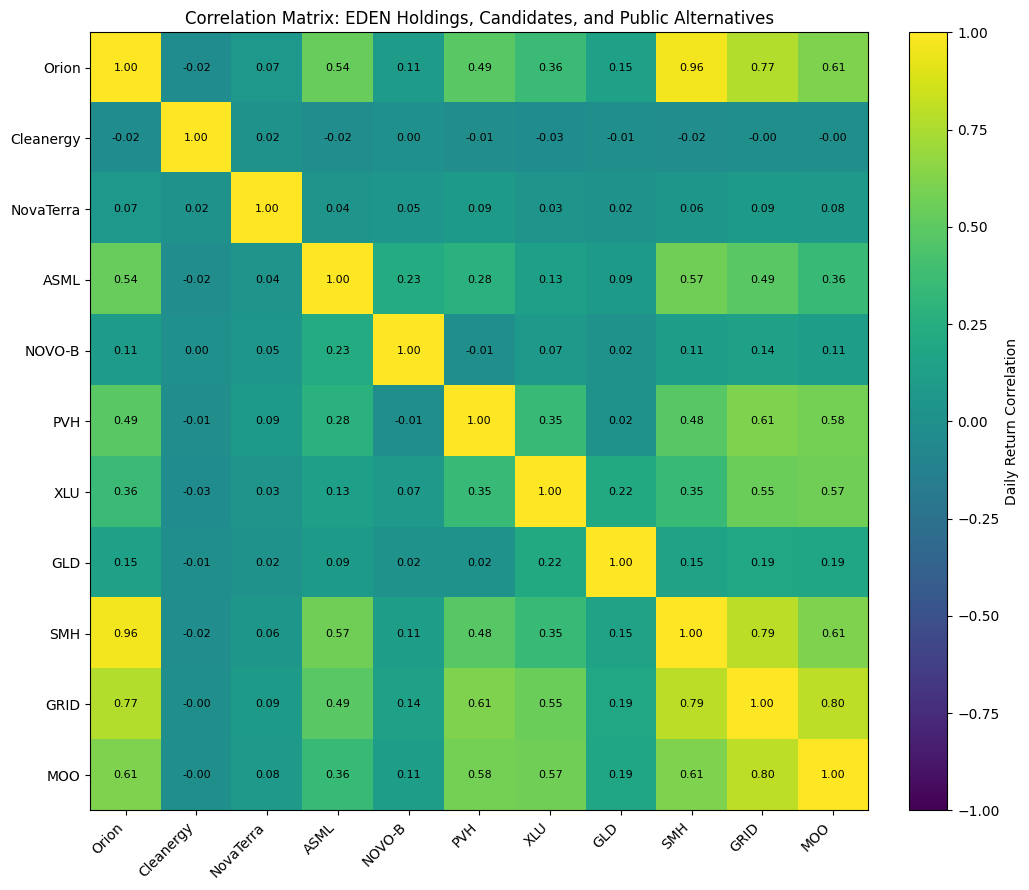

Saved correlation heatmap to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\03_full_correlation_matrix.png


In [11]:
# Visualize full correlation matrix as a heatmap

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Correlation Matrix: EDEN Holdings, Candidates, and Public Alternatives")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Daily Return Correlation")

fig.tight_layout()

correlation_heatmap_path = OUTPUT_CHARTS / "03_full_correlation_matrix.png"

plt.savefig(
    correlation_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved correlation heatmap to:")
print(correlation_heatmap_path)


### Correlation Matrix — Interpretation

The full correlation matrix compares EDEN’s existing holdings, the three fictional candidates, and selected public alternatives. The purpose is not to choose the lowest-correlation asset mechanically, but to assess whether each new €5,000 position adds useful diversification or increases concentration risk within the current ASML/NOVO-B/PVH/XLU/GLD portfolio.

**Orion** shows a moderate positive correlation with ASML (**0.54**) and PVH (**0.49**), and a lower but still positive correlation with XLU (**0.36**). This confirms that Orion is not a clean diversifier for the existing portfolio. More importantly, Orion is extremely highly correlated with SMH (**0.96**), meaning its historical return pattern is very close to diversified semiconductor ETF exposure. This strengthens the concern that Orion may duplicate EDEN’s existing semiconductor / AI-capex exposure through ASML, while also raising the question of why EDEN should take single-name Orion risk instead of using a diversified semiconductor ETF.

**Cleanergy** has correlations close to zero with almost every existing holding and public alternative. Its correlation with ASML is **-0.02**, with PVH **-0.01**, with XLU **-0.03**, and with GLD **-0.01**. From a pure diversification perspective, Cleanergy is the cleanest addition because it contributes a distinct return stream. However, low correlation alone is not enough to justify the investment. The recommendation still needs to test whether Cleanergy’s volatility, drawdown, supplier dependence, and execution risk are acceptable for EDEN’s Learn → Stocks bucket.

**NovaTerra** also has low correlations with the current portfolio, including ASML (**0.04**), NOVO-B (**0.05**), PVH (**0.09**), XLU (**0.03**), and GLD (**0.02**). This means NovaTerra provides diversification benefits similar to Cleanergy from a correlation standpoint. However, its portfolio case is less clearly linked to the current portfolio gap unless the committee values agriculture / resource-productivity exposure as highly as energy-transition infrastructure. Therefore, NovaTerra’s low correlation is helpful, but it does not automatically make it the preferred candidate.

The public alternatives show an important pattern. **SMH** is highly correlated with Orion (**0.96**) and moderately correlated with ASML (**0.57**), confirming that it is a strong semiconductor benchmark but not a strong diversifier. **GRID** is highly correlated with SMH (**0.79**), MOO (**0.80**), PVH (**0.61**), and XLU (**0.55**), suggesting that GRID behaves more like a broad cyclical / infrastructure equity exposure than a pure Cleanergy substitute. **MOO** is also meaningfully correlated with PVH (**0.58**), XLU (**0.57**), GRID (**0.80**), and SMH (**0.61**), which reduces its value as a clean diversification alternative despite its different sector label.

Overall, the matrix supports a key portfolio-construction conclusion: **Cleanergy and NovaTerra provide the strongest correlation diversification**, while **Orion behaves much more like existing semiconductor exposure**. However, the final decision should not be based on correlation alone. The next step is to compare whether each low-correlation candidate improves the portfolio’s volatility, Sharpe ratio, and max drawdown after the €5,000 allocation.

In [13]:
# Define portfolio weights for current, candidate-addition, and public-alternative scenarios

current_portfolio_value = sum(portfolio_values.values())
post_investment_value = current_portfolio_value + NEW_INVESTMENT

scenario_weights = {}

# Current portfolio before new investment
current_weights = pd.Series(0.0, index=all_returns.columns)

for holding, value in portfolio_values.items():
    current_weights[holding] = value / current_portfolio_value

scenario_weights["Current Portfolio"] = current_weights

# Portfolio after adding a €5,000 position in each fictional candidate or public alternative
for asset in scenario_assets:
    weights = pd.Series(0.0, index=all_returns.columns)

    for holding, value in portfolio_values.items():
        weights[holding] = value / post_investment_value

    weights[asset] = NEW_INVESTMENT / post_investment_value

    scenario_weights[f"Add {asset}"] = weights

scenario_weights_df = pd.DataFrame(scenario_weights)

# Validate that each scenario sums to 100%
scenario_weight_sums = scenario_weights_df.sum(axis=0)

print("Scenario weights. The added €5,000 position equals "
      f"{NEW_INVESTMENT / post_investment_value:.1%} of the post-investment portfolio.")
display(scenario_weights_df.round(4))
display(scenario_weight_sums.to_frame("Weight Sum").round(6))

if not np.allclose(scenario_weight_sums.values, 1.0):
    raise ValueError("One or more scenario weight vectors do not sum to 1.")

scenario_weights_path = OUTPUT_TABLES / "03_scenario_weights.csv"
scenario_weights_rounded_path = OUTPUT_TABLES / "03_scenario_weights_rounded.csv"

scenario_weights_df.to_csv(scenario_weights_path)
scenario_weights_df.round(4).to_csv(scenario_weights_rounded_path)

print("Saved scenario weights to:")
print(scenario_weights_path)

print("\nSaved rounded scenario weights to:")
print(scenario_weights_rounded_path)


Scenario weights. The added €5,000 position equals 12.5% of the post-investment portfolio.


,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra,Add SMH,Add GRID,Add MOO
Orion,0.0000,0.1250,0.0000,0.0000,0.0000,0.0000,0.0000
Cleanergy,0.0000,0.0000,0.1250,0.0000,0.0000,0.0000,0.0000
NovaTerra,0.0000,0.0000,0.0000,0.1250,0.0000,0.0000,0.0000
ASML,0.1429,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250
NOVO-B,0.1429,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250
PVH,0.2143,0.1875,0.1875,0.1875,0.1875,0.1875,0.1875
XLU,0.2143,0.1875,0.1875,0.1875,0.1875,0.1875,0.1875
GLD,0.2857,0.2500,0.2500,0.2500,0.2500,0.2500,0.2500
SMH,0.0000,0.0000,0.0000,0.0000,0.1250,0.0000,0.0000
GRID,0.0000,0.0000,0.0000,0.0000,0.0000,0.1250,0.0000


,Weight Sum
Current Portfolio,1.0
Add Orion,1.0
Add Cleanergy,1.0
Add NovaTerra,1.0
Add SMH,1.0
Add GRID,1.0
Add MOO,1.0


Saved scenario weights to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_weights.csv

Saved rounded scenario weights to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_weights_rounded.csv


## Portfolio Scenario Metrics

For each scenario, we calculate cumulative return, annualized return, annualized volatility, Sharpe ratio, and maximum drawdown. The Sharpe ratio uses a 3% annual risk-free-rate assumption, which should be kept consistent with the candidate quant notebook.

In [14]:
# Define reusable function for portfolio return and risk metrics

def calculate_return_metrics(return_series, risk_free_rate=RISK_FREE_RATE):
    return_series = return_series.dropna()

    if len(return_series) == 0:
        raise ValueError("Return series is empty after dropping missing values.")

    cumulative_return = (1 + return_series).prod() - 1

    annualized_return = (
        (1 + cumulative_return) ** (TRADING_DAYS / len(return_series)) - 1
    )

    annualized_volatility = return_series.std() * np.sqrt(TRADING_DAYS)

    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if not np.isclose(annualized_volatility, 0)
        else np.nan
    )

    cumulative_curve = (1 + return_series).cumprod()
    drawdown = cumulative_curve / cumulative_curve.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
    }

In [15]:
# Compute daily return series for current and candidate-addition portfolio scenarios

# Ensure scenario weights are aligned to the return columns
scenario_weights_aligned = scenario_weights_df.loc[all_returns.columns]

# Validate that every scenario weight vector sums to 1
scenario_weight_sums = scenario_weights_aligned.sum(axis=0)

display(scenario_weight_sums.to_frame("Weight Sum").round(6))

if not np.allclose(scenario_weight_sums.values, 1.0):
    raise ValueError("One or more scenario weight vectors do not sum to 1.")

# Matrix multiplication:
# each scenario return = weighted sum of asset returns
portfolio_scenario_returns = all_returns.dot(scenario_weights_aligned)

display(portfolio_scenario_returns.head())
display(portfolio_scenario_returns.tail())

scenario_returns_path = DATA_PROCESSED / "03_portfolio_scenario_daily_returns.csv"
portfolio_scenario_returns.to_csv(scenario_returns_path)

print("Saved portfolio scenario daily returns to:")
print(scenario_returns_path)

,Weight Sum
Current Portfolio,1.0
Add Orion,1.0
Add Cleanergy,1.0
Add NovaTerra,1.0
Add SMH,1.0
Add GRID,1.0
Add MOO,1.0


,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra,Add SMH,Add GRID,Add MOO
2019-06-21,0.006478,0.002714,0.001504,0.006384,0.005076,0.005643,0.005707
2019-06-24,0.002479,0.002947,0.007038,-0.001071,0.002403,0.001934,0.002588
2019-06-25,-0.002664,-0.004187,0.002733,-0.002119,-0.004497,-0.003509,-0.002634
2019-06-26,-0.001952,0.002191,-0.004367,-0.004173,0.001989,-0.000836,-0.001537
2019-06-27,0.000012,0.001720,-0.007375,0.003368,0.001691,0.001166,0.000959


,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra,Add SMH,Add GRID,Add MOO
2026-02-19,0.001620,-0.000531,0.005387,0.002437,0.000705,0.001389,0.003482
2026-02-20,0.013378,0.014205,0.013765,0.011315,0.013177,0.012514,0.011328
2026-02-23,-0.023987,-0.022497,-0.024356,-0.019978,-0.021636,-0.022205,-0.022517
2026-02-24,-0.004570,-0.002446,-0.005628,-0.003877,-0.002097,-0.002053,-0.002923
2026-02-25,-0.001390,0.000150,-0.001901,-0.001257,0.000872,0.000057,-0.002063


Saved portfolio scenario daily returns to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\processed\03_portfolio_scenario_daily_returns.csv


In [16]:
# Calculate risk/return metrics for each portfolio scenario

scenario_metrics = []

for scenario_name in portfolio_scenario_returns.columns:
    metrics = calculate_return_metrics(portfolio_scenario_returns[scenario_name])
    metrics["Scenario"] = scenario_name
    scenario_metrics.append(metrics)

scenario_metrics_df = pd.DataFrame(scenario_metrics)

scenario_metrics_df = scenario_metrics_df[
    [
        "Scenario",
        "Cumulative Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
    ]
]

display(scenario_metrics_df)

# Format metrics for review/presentation
scenario_metrics_display = scenario_metrics_df.copy()

percentage_cols = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
]

for col in percentage_cols:
    scenario_metrics_display[col] = scenario_metrics_display[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )

scenario_metrics_display["Sharpe Ratio"] = scenario_metrics_display["Sharpe Ratio"].map(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

display(scenario_metrics_display)

scenario_metrics_path = OUTPUT_TABLES / "03_before_after_portfolio_metrics.csv"
scenario_metrics_formatted_path = OUTPUT_TABLES / "03_before_after_portfolio_metrics_formatted.csv"

scenario_metrics_df.to_csv(scenario_metrics_path, index=False)
scenario_metrics_display.to_csv(scenario_metrics_formatted_path, index=False)

print("Saved scenario metrics to:")
print(scenario_metrics_path)

print("\nSaved formatted scenario metrics to:")
print(scenario_metrics_formatted_path)

,Scenario,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,Current Portfolio,1.263349,0.143011,0.186312,0.606567,-0.326991
1,Add Orion,1.995141,0.196628,0.215560,0.773000,-0.352183
2,Add Cleanergy,1.243425,0.141358,0.171926,0.647708,-0.380951
3,Add NovaTerra,1.342407,0.149450,0.171212,0.697675,-0.313707
4,Add SMH,1.634100,0.171739,0.194345,0.729312,-0.323375
5,Add GRID,1.389126,0.153171,0.187280,0.657685,-0.335422
6,Add MOO,1.129612,0.131675,0.181515,0.560147,-0.327773


,Scenario,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,Current Portfolio,126.33%,14.30%,18.63%,0.61,-32.70%
1,Add Orion,199.51%,19.66%,21.56%,0.77,-35.22%
2,Add Cleanergy,124.34%,14.14%,17.19%,0.65,-38.10%
3,Add NovaTerra,134.24%,14.95%,17.12%,0.70,-31.37%
4,Add SMH,163.41%,17.17%,19.43%,0.73,-32.34%
5,Add GRID,138.91%,15.32%,18.73%,0.66,-33.54%
6,Add MOO,112.96%,13.17%,18.15%,0.56,-32.78%


Saved scenario metrics to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_before_after_portfolio_metrics.csv

Saved formatted scenario metrics to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_before_after_portfolio_metrics_formatted.csv


In [17]:
# Calculate incremental portfolio impact of each candidate and public alternative

scenario_metrics_indexed = scenario_metrics_df.set_index("Scenario")
current_metrics = scenario_metrics_indexed.loc["Current Portfolio"]

incremental_impact = []

for asset in scenario_assets:
    scenario_name = f"Add {asset}"
    scenario = scenario_metrics_indexed.loc[scenario_name]

    change_return = (
        scenario["Annualized Return"] - current_metrics["Annualized Return"]
    )
    change_volatility = (
        scenario["Annualized Volatility"] - current_metrics["Annualized Volatility"]
    )
    change_sharpe = (
        scenario["Sharpe Ratio"] - current_metrics["Sharpe Ratio"]
    )
    change_drawdown = (
        scenario["Max Drawdown"] - current_metrics["Max Drawdown"]
    )

    incremental_impact.append({
        "Asset Added": asset,
        "Asset Type": asset_type_map[asset],
        "Change in Annualized Return": change_return,
        "Change in Annualized Volatility": change_volatility,
        "Change in Sharpe Ratio": change_sharpe,
        "Change in Max Drawdown": change_drawdown,
        "Drawdown Impact": "Improves" if change_drawdown > 0 else "Worsens",
    })

incremental_impact_df = pd.DataFrame(incremental_impact)
candidate_incremental_impact_df = incremental_impact_df[
    incremental_impact_df["Asset Type"].eq("Fictional Candidate")
].copy()
public_alternative_incremental_impact_df = incremental_impact_df[
    incremental_impact_df["Asset Type"].eq("Public Alternative ETF")
].copy()

print("Incremental impact: fictional candidates and selected public alternatives")
display(incremental_impact_df)

print("\nCandidate-only incremental impact")
display(candidate_incremental_impact_df)

# Format incremental impact table for review/presentation
incremental_impact_display = incremental_impact_df.copy()

percentage_cols = [
    "Change in Annualized Return",
    "Change in Annualized Volatility",
    "Change in Max Drawdown",
]

for col in percentage_cols:
    incremental_impact_display[col] = incremental_impact_display[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )

incremental_impact_display["Change in Sharpe Ratio"] = incremental_impact_display[
    "Change in Sharpe Ratio"
].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")

candidate_incremental_impact_display = incremental_impact_display[
    incremental_impact_display["Asset Type"].eq("Fictional Candidate")
].copy()
public_alternative_incremental_impact_display = incremental_impact_display[
    incremental_impact_display["Asset Type"].eq("Public Alternative ETF")
].copy()

display(incremental_impact_display)

scenario_incremental_impact_path = OUTPUT_TABLES / "03_scenario_incremental_portfolio_impact.csv"
scenario_incremental_impact_formatted_path = OUTPUT_TABLES / "03_scenario_incremental_portfolio_impact_formatted.csv"
incremental_impact_path = OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact.csv"
incremental_impact_formatted_path = (
    OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact_formatted.csv"
)
public_alternative_incremental_impact_path = OUTPUT_TABLES / "03_public_alternative_incremental_portfolio_impact.csv"
public_alternative_incremental_impact_formatted_path = OUTPUT_TABLES / "03_public_alternative_incremental_portfolio_impact_formatted.csv"

incremental_impact_df.to_csv(scenario_incremental_impact_path, index=False)
incremental_impact_display.to_csv(scenario_incremental_impact_formatted_path, index=False)
candidate_incremental_impact_df.to_csv(incremental_impact_path, index=False)
candidate_incremental_impact_display.to_csv(incremental_impact_formatted_path, index=False)
public_alternative_incremental_impact_df.to_csv(public_alternative_incremental_impact_path, index=False)
public_alternative_incremental_impact_display.to_csv(public_alternative_incremental_impact_formatted_path, index=False)

print("Saved full scenario incremental impact table to:")
print(scenario_incremental_impact_path)

print("\nSaved candidate-only incremental impact table to:")
print(incremental_impact_path)

print("\nSaved public-alternative incremental impact table to:")
print(public_alternative_incremental_impact_path)


Incremental impact: fictional candidates and selected public alternatives


,Asset Added,Asset Type,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown,Drawdown Impact
0,Orion,Fictional Candidate,0.053617,0.029248,0.166434,-0.025193,Worsens
1,Cleanergy,Fictional Candidate,-0.001653,-0.014386,0.041141,-0.053960,Worsens
2,NovaTerra,Fictional Candidate,0.006440,-0.015100,0.091108,0.013284,Improves
3,SMH,Public Alternative ETF,0.028728,0.008034,0.122746,0.003616,Improves
4,GRID,Public Alternative ETF,0.010160,0.000968,0.051118,-0.008432,Worsens
5,MOO,Public Alternative ETF,-0.011335,-0.004796,-0.046419,-0.000782,Worsens



Candidate-only incremental impact


,Asset Added,Asset Type,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown,Drawdown Impact
0,Orion,Fictional Candidate,0.053617,0.029248,0.166434,-0.025193,Worsens
1,Cleanergy,Fictional Candidate,-0.001653,-0.014386,0.041141,-0.053960,Worsens
2,NovaTerra,Fictional Candidate,0.006440,-0.015100,0.091108,0.013284,Improves


,Asset Added,Asset Type,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown,Drawdown Impact
0,Orion,Fictional Candidate,5.36%,2.92%,0.17,-2.52%,Worsens
1,Cleanergy,Fictional Candidate,-0.17%,-1.44%,0.04,-5.40%,Worsens
2,NovaTerra,Fictional Candidate,0.64%,-1.51%,0.09,1.33%,Improves
3,SMH,Public Alternative ETF,2.87%,0.80%,0.12,0.36%,Improves
4,GRID,Public Alternative ETF,1.02%,0.10%,0.05,-0.84%,Worsens
5,MOO,Public Alternative ETF,-1.13%,-0.48%,-0.05,-0.08%,Worsens


Saved full scenario incremental impact table to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_incremental_portfolio_impact.csv

Saved candidate-only incremental impact table to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_incremental_portfolio_impact.csv

Saved public-alternative incremental impact table to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_public_alternative_incremental_portfolio_impact.csv


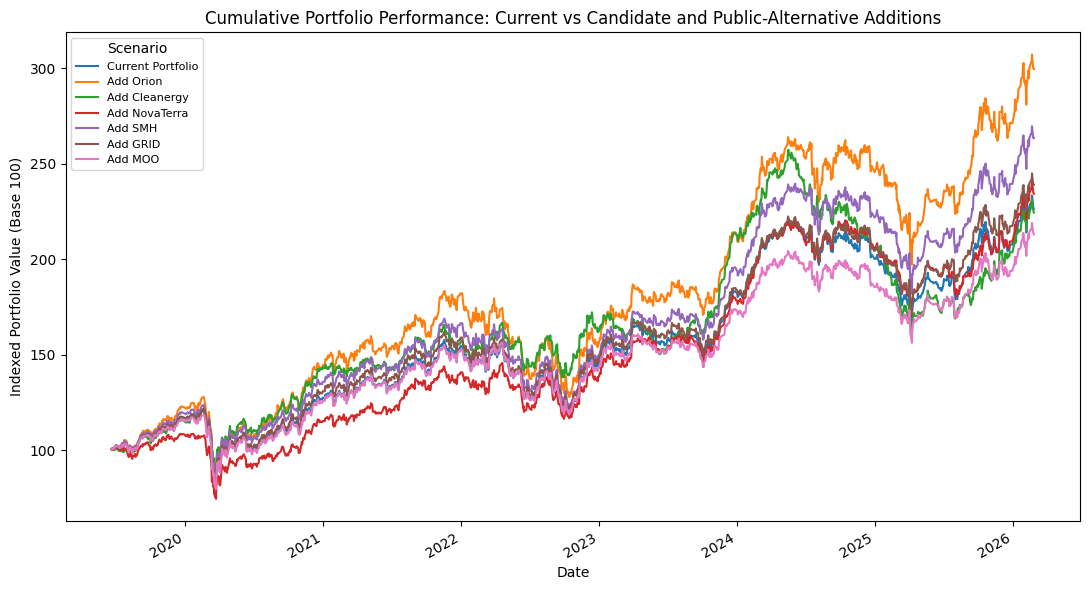

Saved cumulative performance chart to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\03_scenario_cumulative_performance.png


In [18]:
# Plot cumulative portfolio performance for each scenario

# Convert daily returns into cumulative performance, indexed to 100
cumulative_scenarios = (1 + portfolio_scenario_returns).cumprod() * 100

# Create chart
ax = cumulative_scenarios.plot(figsize=(11, 6))

ax.set_title("Cumulative Portfolio Performance: Current vs Candidate and Public-Alternative Additions")
ax.set_ylabel("Indexed Portfolio Value (Base 100)")
ax.set_xlabel("Date")
ax.legend(title="Scenario", fontsize=8)

plt.tight_layout()

# Export chart
cumulative_performance_path = OUTPUT_CHARTS / "03_scenario_cumulative_performance.png"

plt.savefig(
    cumulative_performance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved cumulative performance chart to:")
print(cumulative_performance_path)


### Incremental Portfolio Impact — Interpretation

The incremental-impact table measures how each €5,000 allocation changes EDEN’s current portfolio relative to the base ASML/NOVO-B/PVH/XLU/GLD portfolio. Positive changes in annualized return and Sharpe ratio are favorable. Lower annualized volatility is favorable. For max drawdown, a positive change means the portfolio drawdown improves, while a negative change means the drawdown worsens.

**Orion** has the strongest return and Sharpe contribution. Adding Orion increases annualized return by **5.36 percentage points** and improves the Sharpe ratio by **0.17**, the largest improvement among all tested assets. However, this comes with a clear risk cost: annualized volatility rises by **2.92 percentage points** and max drawdown worsens by **2.52 percentage points**. Therefore, Orion is the highest-upside candidate, but it increases portfolio risk and reinforces the concern from the correlation matrix that EDEN would be adding more semiconductor / AI-related exposure.

**Cleanergy** improves portfolio volatility but weakens the return and drawdown profile. Adding Cleanergy reduces annualized volatility by **1.44 percentage points** and improves the Sharpe ratio slightly by **0.04**, but annualized return falls by **0.17 percentage points** and max drawdown worsens by **5.40 percentage points**. This creates a mixed result: Cleanergy is useful as a low-correlation diversifier, but its historical downside impact is difficult to defend unless the committee strongly prioritizes energy-transition exposure and accepts substantial drawdown risk in the Learn → Stocks bucket.

**NovaTerra** has the cleanest risk-control profile among the fictional candidates. Adding NovaTerra increases annualized return by **0.64 percentage points**, reduces annualized volatility by **1.51 percentage points**, improves the Sharpe ratio by **0.09**, and improves max drawdown by **1.33 percentage points**. This makes NovaTerra the most balanced fictional candidate from an incremental portfolio perspective: it improves return, volatility, Sharpe ratio, and drawdown at the same time. The limitation is that its strategic fit may be less directly linked to the portfolio’s visible energy-transition / infrastructure gap than Cleanergy.

Among the public ETF alternatives, **SMH** is the strongest performer. It increases annualized return by **2.87 percentage points**, improves the Sharpe ratio by **0.12**, and slightly improves max drawdown by **0.36 percentage points**, although it also raises volatility by **0.80 percentage points**. This makes SMH a credible diversified alternative to Orion: it captures semiconductor upside with better drawdown behavior than Orion, but it still increases exposure to a theme already represented by ASML.

**GRID** provides only a modest portfolio improvement. It increases annualized return by **1.02 percentage points** and improves Sharpe by **0.05**, with almost no volatility increase. However, max drawdown worsens by **0.84 percentage points**. Given that GRID is meant to be the diversified alternative to Cleanergy, its results suggest that public smart-grid exposure is more stable than Cleanergy, but not clearly superior from a full portfolio-impact perspective.

**MOO** is the weakest public ETF alternative in this table. It reduces annualized return by **1.13 percentage points**, lowers volatility slightly by **0.48 percentage points**, worsens the Sharpe ratio by **0.05**, and slightly worsens max drawdown. This weakens the case for using broad agribusiness ETF exposure as a substitute for NovaTerra.

Overall, the incremental portfolio evidence favors **NovaTerra** on risk-balanced portfolio impact and **Orion** on upside / Sharpe improvement. Cleanergy remains attractive from a thematic and correlation-diversification perspective, but its negative return contribution and drawdown deterioration weaken the investment case. If the final recommendation prioritizes portfolio risk control, NovaTerra is the strongest fictional candidate. If the recommendation prioritizes high-growth upside and accepts higher risk, Orion remains the main challenger. Cleanergy requires the strongest qualitative defense because the portfolio metrics do not fully support the energy-transition gap argument.

In [19]:
# Export aligned daily returns used in the core portfolio analysis

aligned_returns_path = DATA_PROCESSED / "03_aligned_candidate_portfolio_daily_returns.csv"
all_returns.to_csv(aligned_returns_path)

print("Saved aligned candidate, current-portfolio, and public-alternative daily returns to:")
print(aligned_returns_path)


Saved aligned candidate, current-portfolio, and public-alternative daily returns to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\processed\03_aligned_candidate_portfolio_daily_returns.csv


In [20]:
# Final export summary for notebook 03

print("\nNotebook 03 completed.")
print("Main purpose: portfolio fit, diversification, and candidate / public-alternative scenario analysis.")

print("\nKey tables exported to:")
print(OUTPUT_TABLES / "03_full_correlation_matrix.csv")
print(OUTPUT_TABLES / "03_full_correlation_matrix_rounded.csv")
print(OUTPUT_TABLES / "03_candidate_correlation_summary.csv")
print(OUTPUT_TABLES / "03_candidate_correlation_summary_rounded.csv")
print(OUTPUT_TABLES / "03_scenario_asset_correlation_summary.csv")
print(OUTPUT_TABLES / "03_scenario_asset_correlation_summary_rounded.csv")
print(OUTPUT_TABLES / "03_scenario_weights.csv")
print(OUTPUT_TABLES / "03_scenario_weights_rounded.csv")
print(OUTPUT_TABLES / "03_before_after_portfolio_metrics.csv")
print(OUTPUT_TABLES / "03_before_after_portfolio_metrics_formatted.csv")
print(OUTPUT_TABLES / "03_scenario_incremental_portfolio_impact.csv")
print(OUTPUT_TABLES / "03_scenario_incremental_portfolio_impact_formatted.csv")
print(OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact.csv")
print(OUTPUT_TABLES / "03_candidate_incremental_portfolio_impact_formatted.csv")
print(OUTPUT_TABLES / "03_public_alternative_incremental_portfolio_impact.csv")
print(OUTPUT_TABLES / "03_public_alternative_incremental_portfolio_impact_formatted.csv")

print("\nKey processed data exported to:")
print(DATA_PROCESSED / "03_aligned_candidate_portfolio_daily_returns.csv")
print(DATA_PROCESSED / "03_portfolio_scenario_daily_returns.csv")

print("\nKey charts exported to:")
print(OUTPUT_CHARTS / "03_full_correlation_matrix.png")
print(OUTPUT_CHARTS / "03_scenario_cumulative_performance.png")



Notebook 03 completed.
Main purpose: portfolio fit, diversification, and candidate / public-alternative scenario analysis.

Key tables exported to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_full_correlation_matrix.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_full_correlation_matrix_rounded.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_correlation_summary.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_candidate_correlation_summary_rounded.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_asset_correlation_summary.csv
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\03_scenario_asset_correlation_summary_rounded.csv
c:\Users\Usuario\OneDrive

### Final Notebook 03 Interpretation

Notebook 03 evaluates the candidates from a portfolio-construction perspective rather than as standalone investments. The objective is to test how each €5,000 allocation would change EDEN’s existing ASML/NOVO-B/PVH/XLU/GLD portfolio, using correlation, scenario weights, incremental return, volatility, Sharpe ratio, and max drawdown.

The correlation matrix shows that **Cleanergy** and **NovaTerra** provide the strongest diversification benefit. Both have correlations close to zero with most existing EDEN holdings, suggesting that they add distinct return streams. By contrast, **Orion** is moderately correlated with ASML and highly correlated with SMH, which confirms that it behaves more like concentrated semiconductor / AI exposure than a clean portfolio diversifier.

However, the incremental portfolio-impact analysis changes the interpretation. **Cleanergy** remains attractive from a thematic perspective because it adds grid-scale storage, energy-transition infrastructure, and recurring lease/software exposure. This addresses a visible gap in EDEN’s current portfolio. Nevertheless, the scenario results are mixed: Cleanergy reduces annualized volatility, but it slightly lowers annualized return and materially worsens max drawdown. This weakens the case for Cleanergy unless the final recommendation deliberately prioritizes energy-transition learning value and accepts the historical downside risk.

**NovaTerra** has the strongest balanced portfolio impact among the fictional candidates. Adding NovaTerra increases annualized return, reduces annualized volatility, improves the Sharpe ratio, and improves max drawdown. This makes NovaTerra the cleanest portfolio addition from a risk-adjusted perspective. The main limitation is strategic: its precision-agriculture exposure is diversifying, but it is less directly connected to the portfolio gap initially identified around energy transition, infrastructure, and grid modernization.

**Orion** delivers the strongest upside contribution. It produces the largest increase in annualized return and the largest improvement in Sharpe ratio among the fictional candidates. However, this comes at the cost of higher annualized volatility and a worse max drawdown. Combined with Orion’s overlap with ASML and its very high correlation with SMH, the portfolio evidence suggests that Orion is best understood as a high-conviction semiconductor / AI-growth bet rather than a diversification improvement.

The public ETF alternatives help frame the opportunity cost of each fictional stock. **SMH** provides semiconductor upside with a more diversified structure than Orion, although it still increases exposure to a theme EDEN already owns through ASML. **GRID** offers a cleaner public route to smart-grid and infrastructure exposure than Cleanergy, but its incremental portfolio improvement is only modest and its drawdown impact is still negative. **MOO** is the weakest public alternative in the scenario analysis because it lowers annualized return and Sharpe ratio while providing only limited risk reduction.

Overall, Notebook 03 shows that there is no single perfect candidate. The investment decision depends on the committee’s priority. If EDEN prioritizes the strongest balanced improvement to portfolio risk and return, **NovaTerra** is the leading fictional candidate. If EDEN prioritizes high-growth upside and accepts additional concentration risk, **Orion** remains the main challenger. If EDEN prioritizes strategic energy-transition exposure and learning value, **Cleanergy** remains relevant, but its weaker incremental portfolio metrics must be clearly acknowledged and defended.

These results should feed directly into the final scorecard and recommendation notebook. The final decision should not rely on correlation alone or on standalone performance alone. The most defensible recommendation will be the candidate that best combines portfolio fit, business quality, risk-adjusted evidence, downside control, EDEN compliance, and Q&A defensibility.